# 20 — HbA1c vs Sensor & Physiological Measurements

**Purpose**: Quantify how well each sensor modality (CGM spike metrics, ECG parameters,
wearable activity/physiology) correlates with HbA1c — the clinical gold standard for
glycemic control. Identifies which sensor streams best predict long-term glycemic burden
and characterises participants where HbA1c and CGM metrics disagree (concordance/
discordance analysis).

**Inputs**:
- `13_hba1c_per_person.csv` (Google Drive)
- `17_spike_metrics_per_person.csv` (Google Drive)
- `14_ecg_per_person.csv` (Google Drive)
- Activity monitor manifest: `{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv` (Azure)
- `features_with_cluster.csv` (Google Drive)

**Output**: `20_hba1c_sensor_correlations.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.
Azure connection required for activity monitor manifest only.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'seaborn', 'statsmodels']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings, os, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
STUDY_ID          = '00b62456-0b93-4975-a992-42ba6a50ed5c'

print('Environment ready.')

Environment ready.


In [3]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [4]:
# ── 3. Azure Connection (for activity monitor manifest) ────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-raw'
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('Credentials loaded from local config/azure_config.py')

blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV from Azure Blob directly into a DataFrame."""
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):
Azure connection established.


In [5]:
# ── 4. Load All Data Sources ───────────────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
hba1c_df = pd.read_csv(out_dir / '13_hba1c_per_person.csv')
spike_df = pd.read_csv(out_dir / '17_spike_metrics_per_person.csv')

# ECG — NB14 output
ecg_path = out_dir / '14_ecg_per_person.csv'
if ecg_path.exists():
    ecg_df = pd.read_csv(ecg_path)
    ecg_df.columns = ecg_df.columns.str.strip().str.lower()
    print(f'ECG loaded: {ecg_df.shape}  cols: {ecg_df.columns.tolist()}')
else:
    ecg_df = None
    print('WARNING: 14_ecg_per_person.csv not found — ECG sections will be skipped.')

# Activity monitor manifest from Azure
print('\nLoading activity monitor manifest from Azure...')
act_manifest = load_blob_csv(
    f'{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv', sep='\t')
act_manifest.columns = act_manifest.columns.str.strip().str.lower()
print(f'Activity manifest: {len(act_manifest)} participants')
print(f'Activity columns: {act_manifest.columns.tolist()}')

# Cast all person_id to str before merging
for d in [features, hba1c_df, spike_df, act_manifest]:
    d['person_id'] = d['person_id'].astype(str)
if ecg_df is not None:
    ecg_df['person_id'] = ecg_df['person_id'].astype(str)

# Build joint dataset — inner on HbA1c, left joins for other modalities
df = (features
      .merge(hba1c_df[['person_id', 'hba1c']], on='person_id', how='inner')
      .merge(spike_df, on='person_id', how='left'))

# Activity monitor — keep only pre-aggregated metric columns
ACT_KEEP = [
    'person_id', 'average_heartrate_bpm', 'average_stress_level',
    'average_oxygen_saturation_pct', 'average_respiratory_rate_bpm',
    'average_daily_activity', 'average_active_calories_kcal'
]
act_keep_avail = [c for c in ACT_KEEP if c in act_manifest.columns]
df = df.merge(act_manifest[act_keep_avail], on='person_id', how='left')

if ecg_df is not None:
    ecg_add = ['person_id'] + [c for c in ecg_df.columns
                                if c != 'person_id' and c not in df.columns]
    df = df.merge(ecg_df[ecg_add], on='person_id', how='left')

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'\nJoint dataset: {len(df)} participants')
for col in ['hba1c', 'tar_180', 'qtc', 'average_heartrate_bpm', 'average_stress_level']:
    if col in df.columns:
        print(f'  {col}: {df[col].notna().sum()} non-null')

ECG loaded: (2226, 13)  cols: ['person_id', 'study_group_code', 'study_group_label', 'comorbidity_cluster', 'mean_glucose', 'qtc', 'rate', 'pr', 'qrsd', 'qrs', 'qt', 'p', 't']

Loading activity monitor manifest from Azure...
Activity manifest: 2184 participants
Activity columns: ['person_id', 'wrist_worn_on', 'dominant_hand', 'heartrate_filepath', 'heartrate_record_count', 'average_heartrate_bpm', 'oxygen_saturation_filepath', 'oxygen_saturation_record_count', 'average_oxygen_saturation_pct', 'stress_level_filepath', 'stress_level_record_count', 'average_stress_level', 'sleep_filepath', 'sleep_record_count', 'average_sleep_hours', 'respiratory_rate_filepath', 'respiratory_rate_record_count', 'average_respiratory_rate_bpm', 'physical_activity_filepath', 'physical_activity_num_days', 'average_daily_activity', 'active_calories_filepath', 'active_calories_record_count', 'average_active_calories_kcal', 'sensor_sampling_duration_days', 'manufacturer', 'manufacturer_model_name']

Joint datase

## 5. HbA1c vs CGM Spike Metrics

In [6]:
# ── 5a. Spearman table: all CGM spike metrics vs HbA1c ────────────
CGM_SPIKE_COLS = [
    'mean_glucose', 'tir', 'tar_180', 'tar_250', 'tbr_70',
    'glucose_cv', 'mage', 'spike_count', 'spike_area', 'spike_duration_mean'
]
cgm_available = [
    c for c in CGM_SPIKE_COLS
    if c in df.columns and df[c].notna().sum() > 50
]

print('=== Spearman: CGM spike metrics vs HbA1c ===')
print(f'{"Metric":25s}  {"rho":>8}  {"p":>12}  {"n":>6}')
print('-' * 58)
cgm_corrs = {}
for col in cgm_available:
    sub = df[['hba1c', col]].dropna()
    rho, p = stats.spearmanr(sub['hba1c'], sub[col])
    cgm_corrs[col] = {'rho': round(rho, 4), 'p': p, 'n': len(sub)}
    print(f'{col:25s}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}')

=== Spearman: CGM spike metrics vs HbA1c ===
Metric                          rho             p       n
----------------------------------------------------------
mean_glucose                +0.6767   1.0143e-292    2186
tir                         -0.6684   8.2762e-283    2184
tar_180                     +0.6914   2.4128e-310    2184
tar_250                     +0.6266   1.6890e-238    2184
tbr_70                      -0.2356    6.2538e-29    2184
glucose_cv                  +0.4560   1.3442e-112    2184
mage                        +0.6191   2.4850e-231    2184
spike_count                 +0.5728   1.0806e-190    2184
spike_area                  +0.6724   2.0901e-287    2184
spike_duration_mean         +0.6563   2.6228e-269    2184


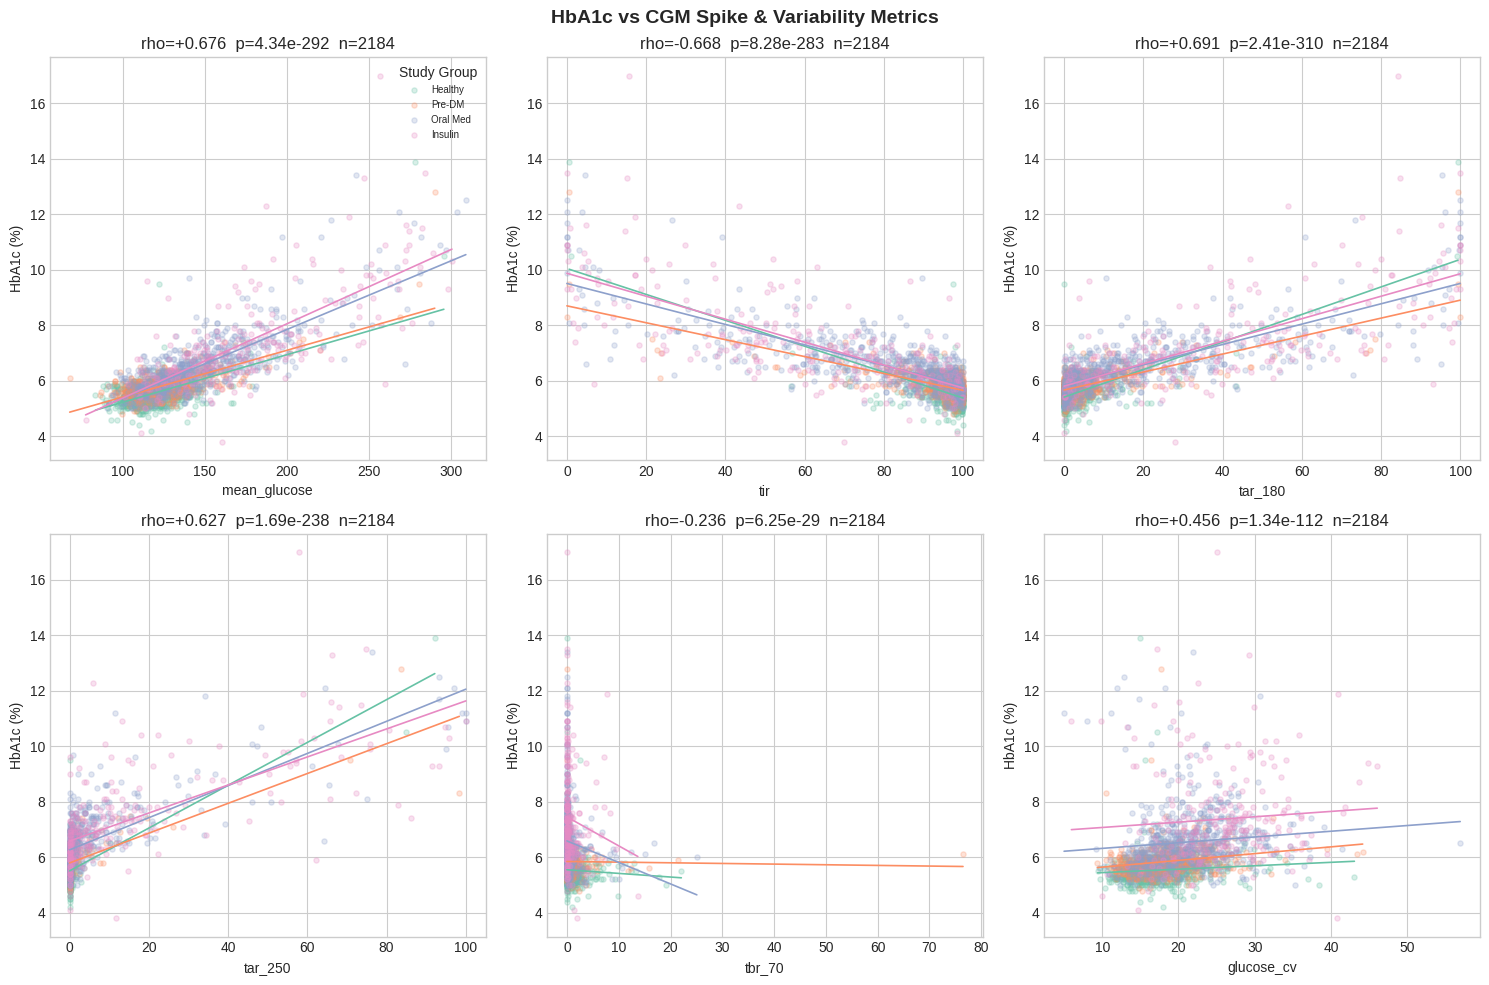

In [7]:
# ── 5b. Scatter matrix: HbA1c vs top CGM metrics ──────────────────
top6_cgm = cgm_available[:6]
n_cols   = min(3, len(top6_cgm))
n_rows   = (len(top6_cgm) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
fig.suptitle('HbA1c vs CGM Spike & Variability Metrics', fontsize=14, fontweight='bold')
axes = np.array(axes).flatten()

for ax, col in zip(axes, top6_cgm):
    sub = df[['hba1c', col, 'study_group_label']].dropna()
    for grp in STUDY_GROUP_ORDER:
        s = sub[sub['study_group_label'] == grp]
        ax.scatter(s[col], s['hba1c'], alpha=0.25, s=14,
                   color=STUDY_GROUP_PAL[grp], label=grp)
        if len(s) > 10:
            m, b, *_ = stats.linregress(s[col], s['hba1c'])
            xs = np.linspace(s[col].min(), s[col].max(), 50)
            ax.plot(xs, m*xs + b, linewidth=1.2, color=STUDY_GROUP_PAL[grp])
    rho, p = stats.spearmanr(sub[col], sub['hba1c'])
    ax.set_xlabel(col); ax.set_ylabel('HbA1c (%)')
    ax.set_title(f'rho={rho:+.3f}  p={p:.2e}  n={len(sub)}')

for ax in axes[len(top6_cgm):]:
    ax.set_visible(False)
if axes[0].has_data():
    axes[0].legend(title='Study Group', fontsize=7)

plt.tight_layout()
plt.show()

## 6. HbA1c vs ECG Metrics

=== Spearman: ECG metrics vs HbA1c ===
Metric           rho             p       n
------------------------------------------
qtc          +0.1030    1.5979e-06    2162
qrs          -0.1196    6.6988e-07    1716
rate         +0.2263    1.6709e-26    2162
pr           +0.1044    1.4267e-06    2125
p            -0.0929    3.1108e-05    2005
t            -0.0901    5.9711e-05    1978
qt           -0.1509    1.7565e-12    2162


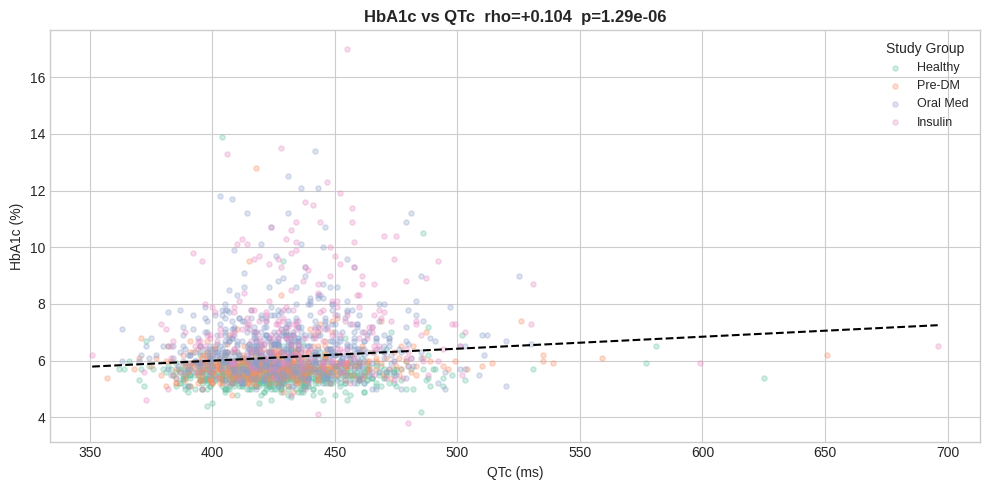

In [8]:
# ── 6. HbA1c vs ECG metrics ───────────────────────────────────────
ECG_COLS_TEST = ['qtc', 'qrs', 'rate', 'pr', 'p', 't', 'qt']
ecg_available = [
    c for c in ECG_COLS_TEST
    if c in df.columns and df[c].notna().sum() > 50
]

if ecg_available:
    print('=== Spearman: ECG metrics vs HbA1c ===')
    print(f'{"Metric":10s}  {"rho":>8}  {"p":>12}  {"n":>6}')
    print('-' * 42)
    ecg_corrs = {}
    for col in ecg_available:
        sub = df[['hba1c', col]].dropna()
        rho, p = stats.spearmanr(sub['hba1c'], sub[col])
        ecg_corrs[col] = {'rho': round(rho, 4), 'p': p, 'n': len(sub)}
        print(f'{col:10s}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}')

    # Scatter: HbA1c vs QTc (primary ECG metric — cardiovascular-metabolic link)
    if 'qtc' in ecg_available:
        sub = df[['hba1c', 'qtc', 'study_group_label']].dropna()
        fig, ax = plt.subplots(figsize=(10, 5))
        for grp in STUDY_GROUP_ORDER:
            s = sub[sub['study_group_label'] == grp]
            ax.scatter(s['qtc'], s['hba1c'], alpha=0.3, s=14,
                       color=STUDY_GROUP_PAL[grp], label=grp)
        m, b, *_ = stats.linregress(sub['qtc'], sub['hba1c'])
        xs = np.linspace(sub['qtc'].min(), sub['qtc'].max(), 100)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.5, linestyle='--')
        rho_qtc, p_qtc = stats.spearmanr(sub['qtc'], sub['hba1c'])
        ax.set_xlabel('QTc (ms)'); ax.set_ylabel('HbA1c (%)')
        ax.set_title(f'HbA1c vs QTc  rho={rho_qtc:+.3f}  p={p_qtc:.2e}',
                     fontweight='bold')
        ax.legend(title='Study Group', fontsize=9)
        plt.tight_layout(); plt.show()
else:
    print('ECG data not available in merged dataset — section skipped.')
    ecg_corrs = {}
    ecg_available = []

## 7. HbA1c vs Activity Monitor Metrics

In [9]:
# ── 7a. Spearman table: activity metrics vs HbA1c ─────────────────
ACT_OUTCOME = [
    'average_heartrate_bpm', 'average_stress_level',
    'average_oxygen_saturation_pct', 'average_respiratory_rate_bpm',
    'average_daily_activity', 'average_active_calories_kcal'
]
act_available = [
    c for c in ACT_OUTCOME
    if c in df.columns and df[c].notna().sum() > 50
]

print('=== Spearman: Activity monitor metrics vs HbA1c ===')
print(f'{"Metric":40s}  {"rho":>8}  {"p":>12}  {"n":>6}')
print('-' * 72)
act_corrs = {}
for col in act_available:
    sub = df[['hba1c', col]].dropna()
    rho, p = stats.spearmanr(sub['hba1c'], sub[col])
    act_corrs[col] = {'rho': round(rho, 4), 'p': p, 'n': len(sub)}
    print(f'{col:40s}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}')

=== Spearman: Activity monitor metrics vs HbA1c ===
Metric                                         rho             p       n
------------------------------------------------------------------------
average_heartrate_bpm                      +0.1157    1.7071e-07    2030
average_stress_level                       +0.1243    1.7979e-08    2038
average_oxygen_saturation_pct              -0.1155    4.0780e-06    1584
average_respiratory_rate_bpm               +0.0441    4.6693e-02    2039
average_daily_activity                     -0.0238    2.7981e-01    2067
average_active_calories_kcal               -0.0349    1.0872e-01    2108


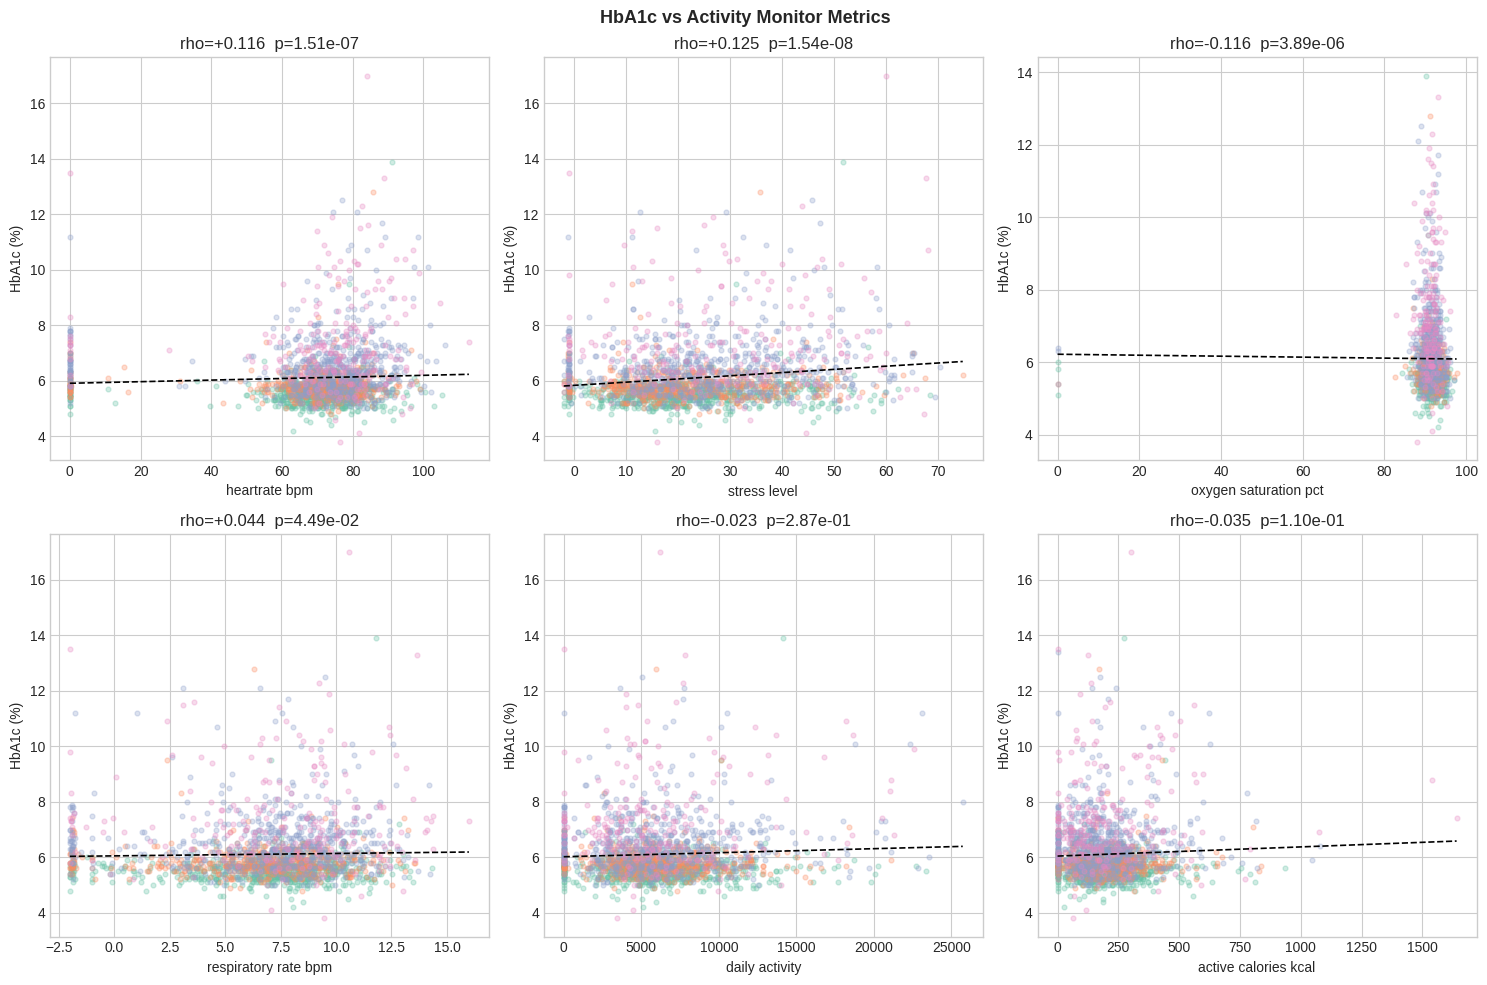

In [10]:
# ── 7b. Scatter grid for activity metrics ─────────────────────────
if act_available:
    n_cols = min(3, len(act_available))
    n_rows = (len(act_available) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    fig.suptitle('HbA1c vs Activity Monitor Metrics', fontsize=13, fontweight='bold')
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, act_available):
        sub = df[['hba1c', col, 'study_group_label']].dropna()
        for grp in STUDY_GROUP_ORDER:
            s = sub[sub['study_group_label'] == grp]
            ax.scatter(s[col], s['hba1c'], alpha=0.3, s=12,
                       color=STUDY_GROUP_PAL[grp], label=grp)
        rho, p = stats.spearmanr(sub[col], sub['hba1c'])
        m, b, *_ = stats.linregress(sub[col], sub['hba1c'])
        xs = np.linspace(sub[col].min(), sub[col].max(), 100)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.2, linestyle='--')
        ax.set_xlabel(col.replace('average_', '').replace('_', ' '))
        ax.set_ylabel('HbA1c (%)')
        ax.set_title(f'rho={rho:+.3f}  p={p:.2e}')

    for ax in axes[len(act_available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## 8. Comprehensive Sensor Correlation Heatmap

All available sensor metrics vs HbA1c and vs each other.

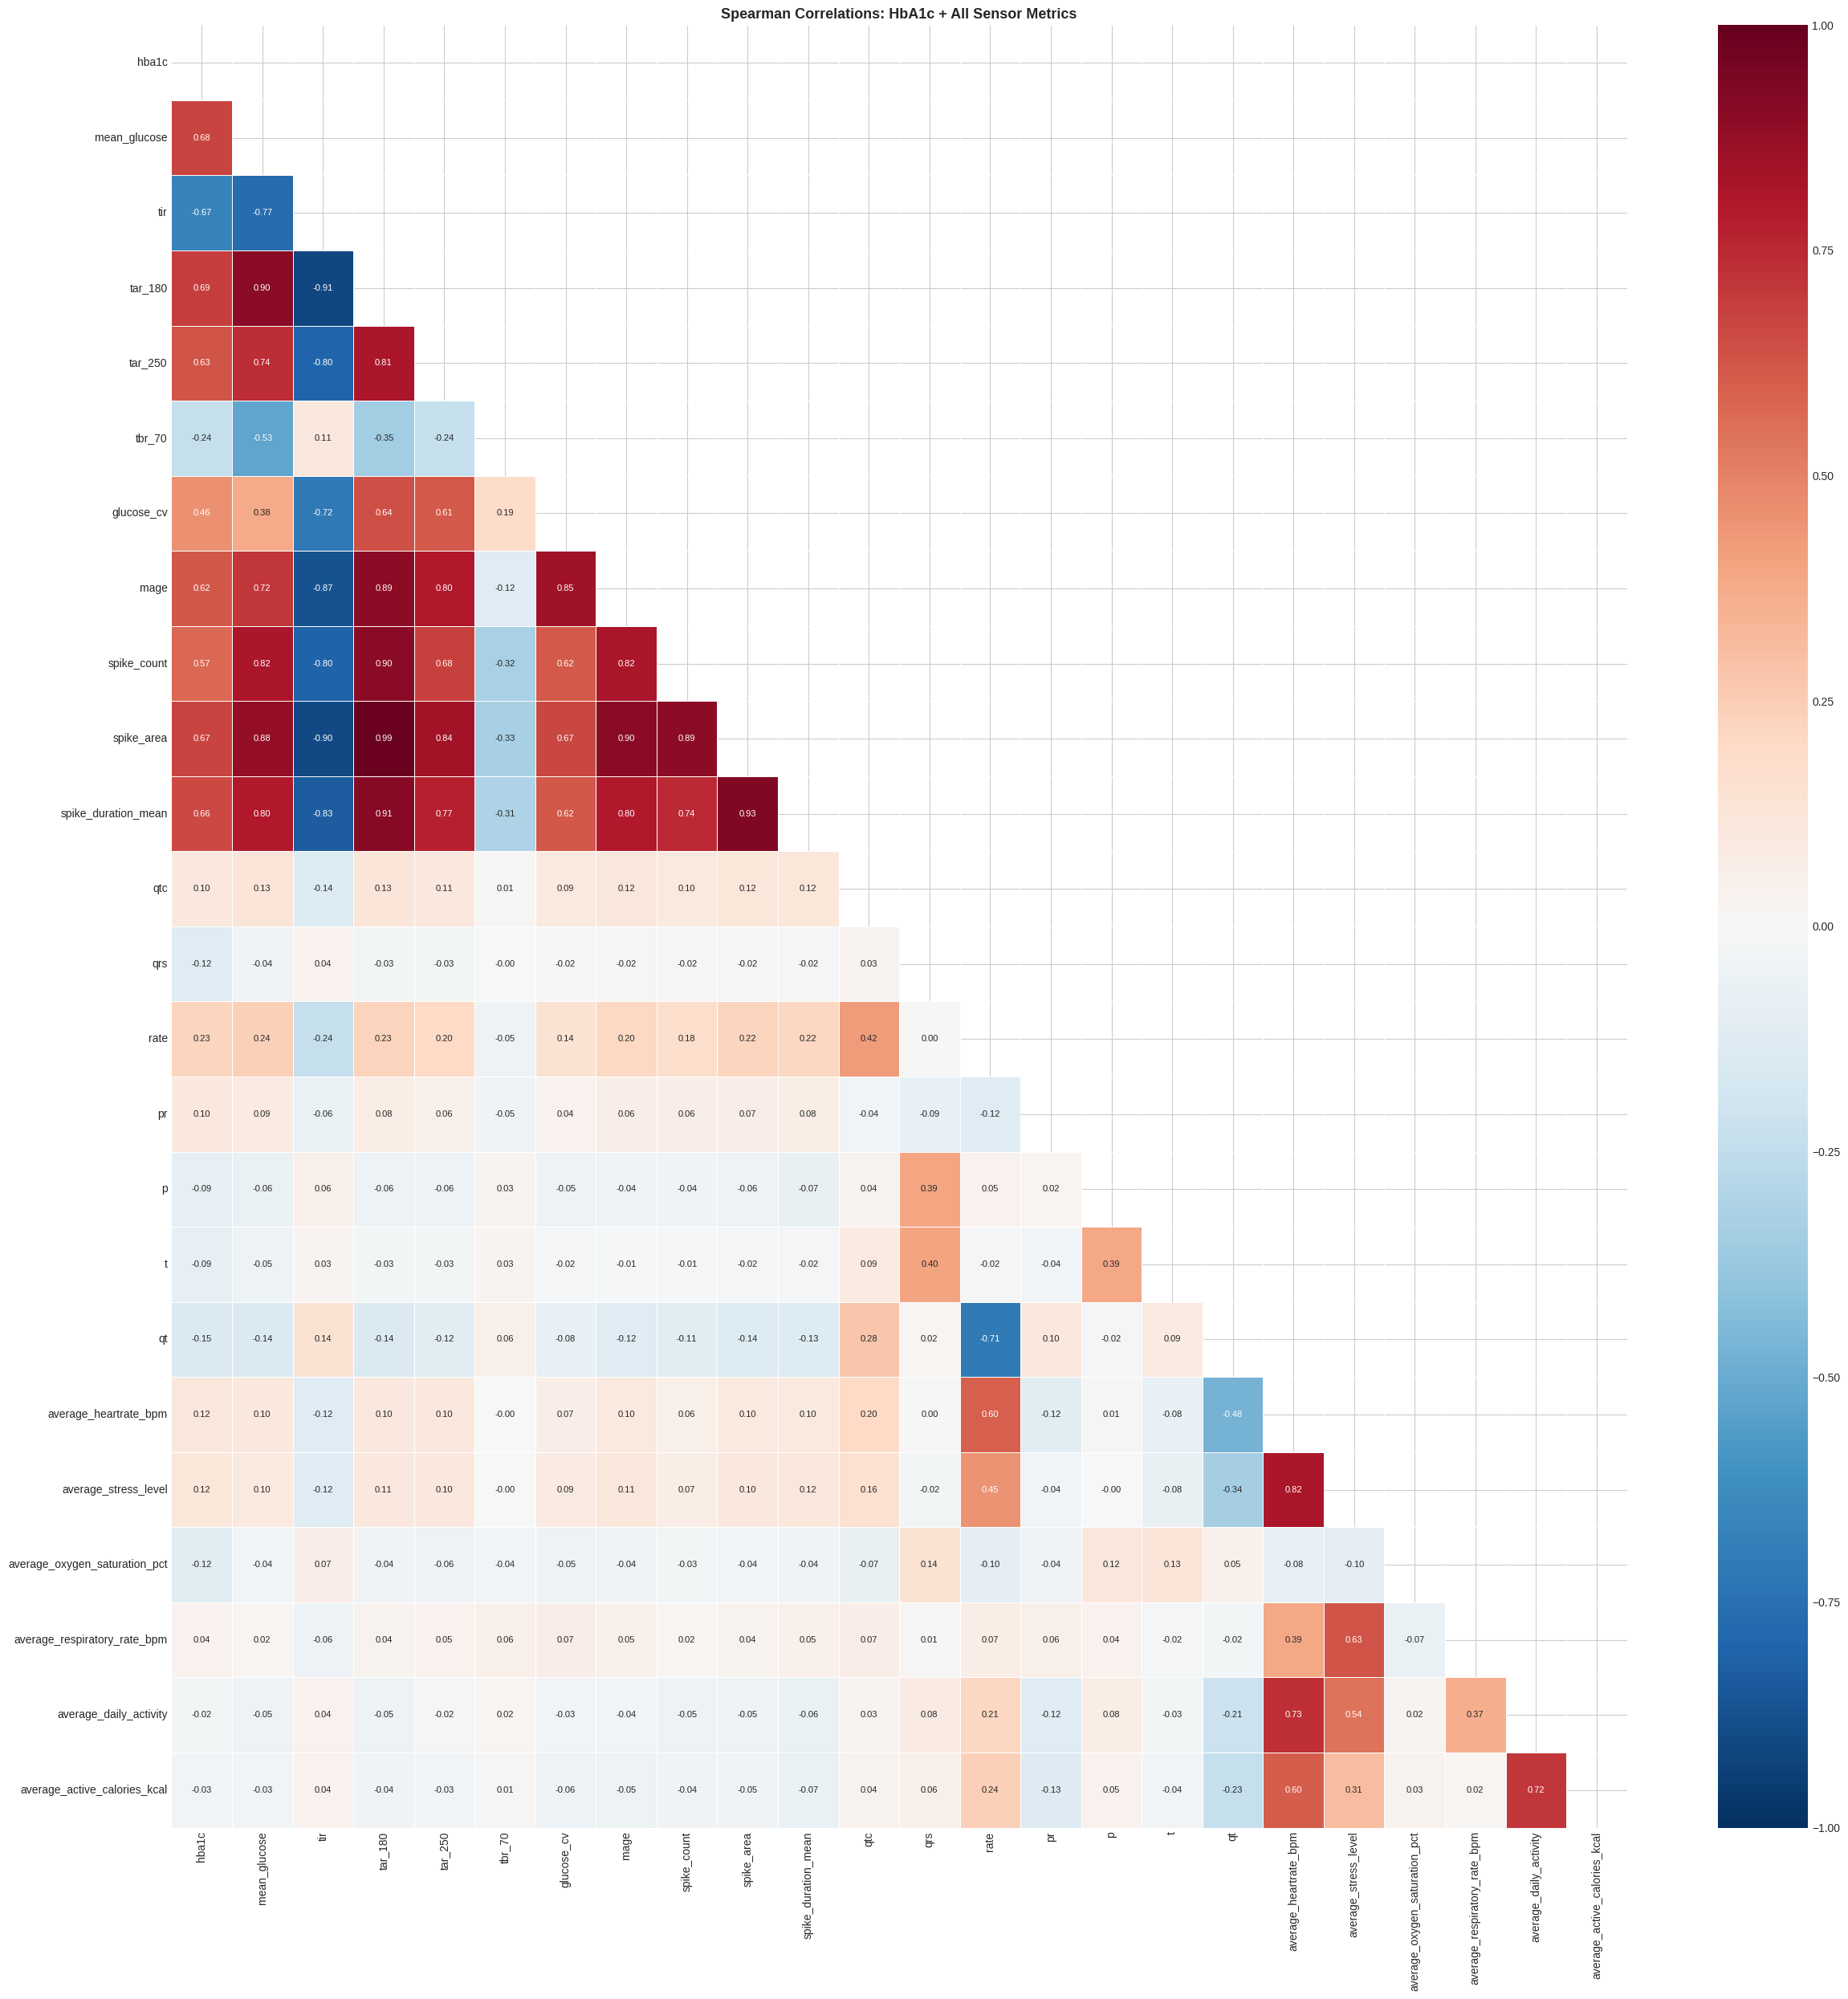

In [11]:
# ── 8. Sensor correlation heatmap ─────────────────────────────────
all_sensor_cols = cgm_available + ecg_available + act_available
sensor_sub      = df[['hba1c'] + all_sensor_cols].copy()
corr_mat        = sensor_sub.corr(method='spearman')

fig_size = max(14, len(all_sensor_cols) + 2)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlations: HbA1c + All Sensor Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Concordance / Discordance Analysis

Identifies participants where HbA1c and mean CGM glucose rank differently.
- **Concordant High**: top-quartile HbA1c AND top-quartile mean_glucose
- **Discordant (High HbA1c / Low CGM)**: top-quartile HbA1c but bottom-half mean_glucose
- **Concordant Low**: bottom-quartile on both

Discordant participants may reflect stress-related cortisol elevation, hemoglobin
variants affecting HbA1c assay accuracy, or SDOH barriers to acute glucose management.

In [12]:
# ── 9. Concordance / discordance analysis ─────────────────────────
sub = df[[
    'person_id', 'hba1c', 'mean_glucose', 'study_group_label',
    'food_housing_insecurity', 'discrimination_score',
    'healthcare_access_barriers', 'paid_total'
]].dropna(subset=['hba1c', 'mean_glucose']).copy()

sub['hba1c_q']   = pd.qcut(sub['hba1c'],        4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
sub['glucose_q'] = pd.qcut(sub['mean_glucose'],  4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

sub['concordance'] = 'Other'
sub.loc[(sub['hba1c_q'] == 'Q4') & (sub['glucose_q'] == 'Q4'),
        'concordance'] = 'Concordant High'
sub.loc[(sub['hba1c_q'] == 'Q4') & sub['glucose_q'].isin(['Q1', 'Q2']),
        'concordance'] = 'Discordant (High HbA1c/Low CGM)'
sub.loc[(sub['hba1c_q'] == 'Q1') & (sub['glucose_q'] == 'Q1'),
        'concordance'] = 'Concordant Low'

print('Concordance group sizes:')
print(sub['concordance'].value_counts())

# Study group composition by concordance
print('\nStudy group composition by concordance:')
print(sub.groupby('concordance')['study_group_label'].value_counts(normalize=True).round(3))

Concordance group sizes:
concordance
Other                              1494
Concordant High                     392
Concordant Low                      279
Discordant (High HbA1c/Low CGM)      21
Name: count, dtype: int64

Study group composition by concordance:
concordance                      study_group_label
Concordant High                  Oral Med            0.556
                                 Insulin             0.357
                                 Pre-DM              0.064
                                 Healthy             0.023
Concordant Low                   Healthy             0.669
                                 Pre-DM              0.191
                                 Oral Med            0.115
                                 Insulin             0.025
Discordant (High HbA1c/Low CGM)  Oral Med            0.524
                                 Insulin             0.286
                                 Healthy             0.143
                                 Pre

n Concordant High: 392
n Discordant:      21

=== SDOH: Concordant High vs Discordant ===
Feature                               Conc-High     Discord        d         p
------------------------------------------------------------------------------
food_housing_insecurity                   0.597       0.810   +0.474    0.0523
discrimination_score                     17.817       2.108   -0.237    0.1515
healthcare_access_barriers                2.480       3.048   +0.168    0.0818
paid_total                                5.261       3.952   -0.263    0.1528


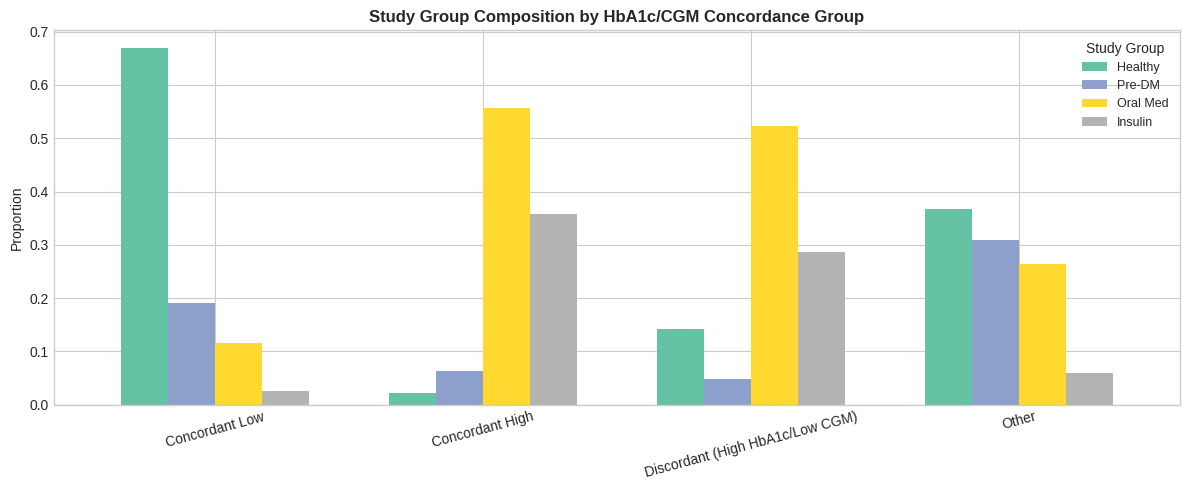

In [13]:
# ── 9b. SDOH comparison: Concordant High vs Discordant ────────────
sdoh_compare = [
    'food_housing_insecurity', 'discrimination_score',
    'healthcare_access_barriers', 'paid_total'
]
conc_h  = sub[sub['concordance'] == 'Concordant High']
discord = sub[sub['concordance'] == 'Discordant (High HbA1c/Low CGM)']

print(f'n Concordant High: {len(conc_h)}')
print(f'n Discordant:      {len(discord)}')

if len(conc_h) >= 10 and len(discord) >= 10:
    print('\n=== SDOH: Concordant High vs Discordant ===')
    print(f'{"Feature":35s}  {"Conc-High":>10s}  {"Discord":>10s}  '
          f'{"d":>7s}  {"p":>8s}')
    print('-' * 78)
    for col in sdoh_compare:
        if col not in sub.columns:
            continue
        a = conc_h[col].dropna()
        b = discord[col].dropna()
        if len(a) < 5 or len(b) < 5:
            continue
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        d = ((b.mean() - a.mean()) /
             np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2))
        print(f'{col:35s}  {a.mean():10.3f}  {b.mean():10.3f}  '
              f'{d:+7.3f}  {p:8.4f}')
else:
    print('\nCell sizes too small for SDOH comparison — reporting counts only.')

# Bar chart: study group composition
concordance_groups = ['Concordant Low', 'Concordant High',
                      'Discordant (High HbA1c/Low CGM)', 'Other']
comp = (sub.groupby('concordance')['study_group_label']
           .value_counts(normalize=True)
           .unstack(fill_value=0)
           .reindex(index=concordance_groups, fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
comp.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_title('Study Group Composition by HbA1c/CGM Concordance Group',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Study Group', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Ranked Summary: All Sensor Metrics vs HbA1c & Export

In [14]:
# ── 10. Build ranked table & export ──────────────────────────────
all_corr = {}
for col in all_sensor_cols:
    sub = df[['hba1c', col]].dropna()
    if len(sub) < 30:
        continue
    rho, p = stats.spearmanr(sub['hba1c'], sub[col])
    all_corr[col] = {
        'sensor_type': ('CGM'      if col in cgm_available else
                        'ECG'      if col in ecg_available else 'Activity'),
        'rho':         round(rho, 4),
        'p':           round(p, 6),
        'n':           len(sub),
        'sig':         ('***' if p < 0.001 else
                        ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
    }

ranked_df = (pd.DataFrame(all_corr).T
               .sort_values('rho', key=abs, ascending=False))
print('=== All Sensor Metrics vs HbA1c (ranked by |ρ|) ===')
print(ranked_df.to_string())

ranked_df.to_csv(out_dir / '20_hba1c_sensor_correlations.csv')
print('\nSaved 20_hba1c_sensor_correlations.csv')

=== All Sensor Metrics vs HbA1c (ranked by |ρ|) ===
                              sensor_type    rho     p     n  sig
tar_180                               CGM  0.691 0.000  2184  ***
mean_glucose                          CGM  0.677 0.000  2186  ***
spike_area                            CGM  0.672 0.000  2184  ***
tir                                   CGM -0.668 0.000  2184  ***
spike_duration_mean                   CGM  0.656 0.000  2184  ***
tar_250                               CGM  0.627 0.000  2184  ***
mage                                  CGM  0.619 0.000  2184  ***
spike_count                           CGM  0.573 0.000  2184  ***
glucose_cv                            CGM  0.456 0.000  2184  ***
tbr_70                                CGM -0.236 0.000  2184  ***
rate                                  ECG  0.226 0.000  2162  ***
qt                                    ECG -0.151 0.000  2162  ***
average_stress_level             Activity  0.124 0.000  2038  ***
qrs                     

## 11. Key Findings

- **CGM spike metrics outperform mean glucose as HbA1c proxies**: TAR >180 is the single strongest HbA1c correlate across all sensors (rho=+0.6914, p=2.41e-310), slightly ahead of mean_glucose (rho=+0.6767) and spike_area (rho=+0.6724). TIR is the strongest negative correlate (rho=−0.6684). This demonstrates that hyperglycemia burden metrics capture additional HbA1c-relevant information beyond what average glucose alone provides.

- **Top 10 HbA1c correlates are all CGM metrics**: tar_180 (0.691), mean_glucose (0.677), spike_area (0.672), tir (−0.668), spike_duration_mean (0.656), tar_250 (0.627), mage (0.619), spike_count (0.573), glucose_cv (0.456), tbr_70 (−0.236). ECG and wearables are dramatically weaker.

- **ECG: modest associations, heart rate leads**: ECG heart rate (rho=+0.226, p<0.001) is the strongest ECG-HbA1c correlate, likely reflecting autonomic neuropathy in more severe diabetes. QTc is significant but modest (rho=+0.103, p<0.001). Notably, QT interval is negatively correlated (rho=−0.151), reflecting rate correction effects. These ECG-glycemia associations are real but reflect confounding through disease severity more than direct metabolic linkage.

- **Activity monitor: all weak (|rho| ≤ 0.124)**: Stress level (rho=+0.124) and heart rate (rho=+0.116) are the strongest wearable predictors — both reflecting the cardiometabolic burden of more severe disease rather than a direct glycemic pathway. Oxygen saturation is negatively correlated (rho=−0.116). Daily activity and active calories are not significantly associated with HbA1c (both p>0.10).

- **Concordance/discordance**: 392 participants (17.9%) are concordant high (top-quartile HbA1c and CGM); 279 (12.8%) concordant low; only 21 (1.0%) discordant (high HbA1c with low CGM). The discordant group is dominated by Oral Med (52.4%) and Insulin (28.6%) patients — too small for robust SDOH analysis but their disease severity composition suggests that HbA1c-CGM disagreement occurs mainly in medicated patients, consistent with the medication-related suppression of acute glucose spikes.

- **Modeling implication**: For predicting HbA1c from non-lab sensors, tar_180 and tir from CGM are by far the most informative features. ECG and wearables add marginal independent signal and are not recommended as HbA1c proxies. A CGM-only model using tar_180 + mean_glucose + glucose_cv would likely capture the majority of HbA1c variance accessible from sensor data.